# Lab 03: Spark I — DataFrame and SQL

Last week we wrote `map → shuffle → reduce` and the **(sum, count) partial aggregate**
by hand to compute the mean temperature per station in a distributed way. However many
partitions we chopped the data into, the answer matched the serial result to within
$10^{-12}$. Today we rewrite that **same aggregation** in a few lines of `DataFrame` and `SQL` on a real distributed engine,
**Apache Spark**. Spark handles partitioning, shuffling, partial aggregation and query plan optimization for us.

Today's deliverable is a **basic ETL (Extract, Transform, Load) pipeline**: read the raw observation CSV
(Extract) → clean missing values and duplicates and derive new columns (Transform) →
aggregate per station and per hour and save a clean table (Load). This pipeline
underpins the **"ingest observations → align in space-time"** stretch of the
end-of-semester closed-loop twin.

## Learning Objectives

By the end of this lab you will be able to:

- Start a **SparkSession** in local mode and explain the driver–executor–partition
  structure and **lazy execution** (transformation vs action).
- Read a CSV with an explicit **schema** (Extract) and understand the difference from
  inferSchema in terms of reproducibility and performance.
- **Clean** missing values and duplicates and derive new columns with `select`,
  `filter`, `withColumn` and `dropDuplicates` (Transform).
- Compute per-station and per-hour statistics with `groupBy().agg()` and verify
  numerically that the result **matches** a serial pandas computation.
- Write the same aggregation in **Spark SQL** (`createOrReplaceTempView` +
  `spark.sql`) and confirm it is identical to the DataFrame API. Cover `join`, window
  functions and UDFs too.
- Read the **query plan** with `explain()`.


In [1]:

import os, sys, time, glob, tempfile, shutil

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
rng = np.random.default_rng(0)        # reproducibility: fixed seed

# Force the Python workers to run with *this* interpreter.
# (Otherwise Spark may pick up another python on PATH and the worker dies for lack of pyspark.)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Today's generated data and ETL outputs stay inside this temporary directory
# (the course repository is untouched).
WORK = tempfile.mkdtemp(prefix="course410_wk03_")
print("working directory:", WORK)
print("python           :", sys.version.split()[0], "| interpreter:", sys.executable)


working directory: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk03_azdq6hv6
python           : 3.11.0 | interpreter: /Users/pepc/Teaching/410/.venv/bin/python


---
## 1. Starting a SparkSession — driver, executor, partition

Spark chops data into **partitions** that several **executors** (worker processes)
process in parallel, all conducted by a **driver** (our notebook). Today we run it inside one
machine in **local mode** (`master("local[*]")`, `*` = all cores) — conceptually
identical to a cluster.

| Component | Role | In local mode |
|---|---|---|
| **Driver** | builds the plan, distributes work, collects results | this notebook process |
| **Executor** | performs the actual computation per partition | a thread per CPU core |
| **Partition** | a slice of the data (≈ Week 2's 'block') | the unit of parallelism in `local[*]` |

We create exactly one SparkSession, reuse it throughout the notebook, and clean up at
the very end.


In [2]:

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .master("local[*]")                              # local, all cores
    .appName("course410-week03")
    .config("spark.sql.shuffle.partitions", "8")     # partitions after a shuffle (small, for local)
    .config("spark.sql.session.timeZone", "Asia/Seoul")
    .config("spark.ui.showConsoleProgress", "false") # headless: no progress bar
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")              # keep log noise down

print("Spark version      :", spark.version)
print("master             :", spark.sparkContext.master)
print("default parallelism:", spark.sparkContext.defaultParallelism, "(~ number of cores in use)")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/20 15:11:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version      : 4.2.0
master             : local[*]
default parallelism: 11 (~ number of cores in use)


Let us start with the smallest distributed collection, `spark.range(n)`, and *look* at
how the data is split into partitions. `rdd.glom()` bundles the contents of each
partition into a list, so we can count the elements per partition.


In [3]:

N = 1_000
df_range = spark.range(N)                    # 0..N-1, spread over several partitions
n_parts = df_range.rdd.getNumPartitions()    # Resilient Distributed Dataset 
per_part = df_range.rdd.glom().map(len).collect()   # elements per partition

print(f"range({N}) -> {n_parts} partitions, total {sum(per_part)}")
print("elements per partition:", per_part)
print("-> Spark splits the data (almost) evenly across the cores for parallel processing.")


range(1000) -> 11 partitions, total 1000
elements per partition: [90, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91]
-> Spark splits the data (almost) evenly across the cores for parallel processing.


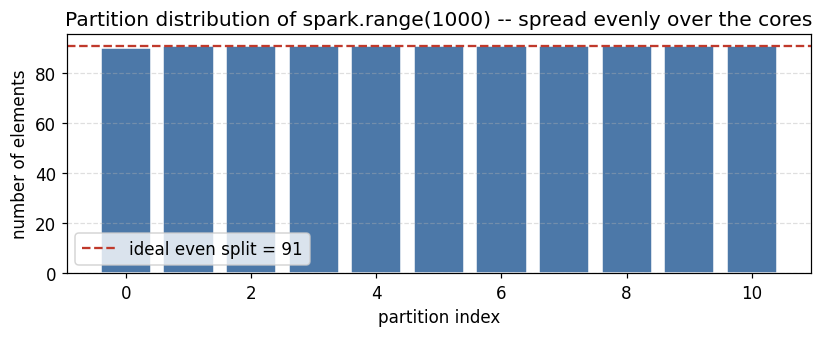

In [4]:

# Elements per partition as bars -- checking the even split (load balancing).
fig, ax = plt.subplots(figsize=(7.6, 3.2))
ax.bar(range(n_parts), per_part, color="#4c78a8", edgecolor="white")
ax.axhline(N / n_parts, ls="--", color="#c0392b",
           label=f"ideal even split = {N/n_parts:.0f}")
ax.set_xlabel("partition index"); ax.set_ylabel("number of elements")
ax.set_title(f"Partition distribution of spark.range({N}) -- spread evenly over the cores")
ax.grid(True, ls="--", alpha=0.4, axis="y"); ax.legend()
plt.tight_layout()


> **Observe:** `range(1000)` was split almost evenly into **n_parts partitions** (the core
> count) — each partition corresponds to Week 2's 'block' and each core to a 'node'.
> Spark hands those partitions to executors for parallel processing. The engine is
> doing the job of the `partition()` function we used to write by hand. Next it is
> time to put **real observational data** on top of this.

---
## 2. Observations and DataFrames — the schema comes first

Now we extend the synthetic **AWS weather observations** of Week 2: the same 5
stations (Seoul, Incheon, Daejeon, Daegu, Busan), the same base_temp, but this time
**three days of hourly** data with a few missing values (the sentinel `-99.0`) and
duplicates mixed in — we need something to clean (ETL). We save it as CSV first and
then read it with Spark.

A Spark `DataFrame` looks like a pandas table of **rows and columns**, but it is
distributed over partitions and evaluated **lazily**. And one
crucial difference: a DataFrame carries an explicit **schema**, i.e. column names and
**types**.


In [5]:

# --- Station metadata (in KMA station-number style). ---
STATIONS = [
    # station, name,   lat,    lon,    region
    (108, "Seoul",   37.57, 126.97, "Capital"),
    (112, "Incheon", 37.48, 126.62, "Capital"),
    (133, "Daejeon", 36.37, 127.37, "Chungcheong"),
    (143, "Daegu",   35.88, 128.62, "Yeongnam"),
    (159, "Busan",   35.10, 129.03, "Yeongnam"),
]
BASE_TEMP = {108: 26.0, 112: 24.5, 133: 27.5, 143: 23.0, 159: 28.5}  # same as Week 2

# --- Generate three days of hourly observations (deterministically). Some stations report twice an hour. ---
gen = np.random.default_rng(1)
rows = ["station,datetime,temp,humidity"]
n_missing = n_dup = 0
records = []                               # (station, datetime, temp, humidity) valid source rows
for day in range(1, 4):                     # 2025-08-01 .. 03
    for h in range(24):
        diurnal = 3.0 * np.sin(2 * np.pi * (h - 9) / 24)   # afternoon peak
        for s, name, lat, lon, region in STATIONS:
            reps = 2 if s in (108, 133) else 1              # unbalanced sample counts
            for _ in range(reps):
                t = BASE_TEMP[s] + diurnal + float(gen.normal(0, 0.6))
                rh = float(np.clip(70 - 1.5 * (t - 24) + gen.normal(0, 3), 20, 100))
                dt = f"2025-08-{day:02d}T{h:02d}:00"
                if gen.random() < 0.04:                     # ~4% missing sentinel
                    rows.append(f"{s},{dt},-99.0,{rh:.1f}"); n_missing += 1
                else:
                    rows.append(f"{s},{dt},{t:.2f},{rh:.1f}")
                    records.append((s, dt, round(t, 2), round(rh, 1)))

# Append a few exactly identical rows as duplicates (for the de-duplication exercise).
dup_src = [r for r in rows[1:] if not r.endswith("-99.0," + r.split(",")[-1])][:8]
for r in dup_src:
    rows.append(r); n_dup += 1

CSV = os.path.join(WORK, "aws_obs.csv")
with open(CSV, "w") as f:
    f.write("\n".join(rows) + "\n")

print(f"created: {CSV}")
print(f"  {len(rows)-1} rows in total ({n_missing} missing, {n_dup} duplicated)")
print("first 5 lines:")
for line in rows[:5]:
    print("  ", line)


created: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk03_azdq6hv6/aws_obs.csv
  512 rows in total (19 missing, 8 duplicated)
first 5 lines:
   station,datetime,temp,humidity
   108,2025-08-01T00:00,24.09,72.3
   108,2025-08-01T00:00,23.10,74.1
   112,2025-08-01T00:00,22.06,74.7
   133,2025-08-01T00:00,25.56,67.8


Let us first build a small DataFrame from a Python list with an **explicit schema**.
`StructType` prescribes each column's name, type and nullability. Declaring the schema
yourself lets you verify, like a contract, that the data arrived with the intended
types.


In [6]:

station_schema = T.StructType([
    T.StructField("station", T.IntegerType(), False),
    T.StructField("name",    T.StringType(),  False),
    T.StructField("lat",     T.DoubleType(),  False),
    T.StructField("lon",     T.DoubleType(),  False),
    T.StructField("region",  T.StringType(),  False),
])
stations_df = spark.createDataFrame(STATIONS, schema=station_schema)

print("stations_df schema:")
stations_df.printSchema()
stations_df.show(truncate=False)
print("rows:", stations_df.count(), "| columns:", stations_df.columns)


stations_df schema:
root
 |-- station: integer (nullable = false)
 |-- name: string (nullable = false)
 |-- lat: double (nullable = false)
 |-- lon: double (nullable = false)
 |-- region: string (nullable = false)

+-------+-------+-----+------+-----------+
|station|name   |lat  |lon   |region     |
+-------+-------+-----+------+-----------+
|108    |Seoul  |37.57|126.97|Capital    |
|112    |Incheon|37.48|126.62|Capital    |
|133    |Daejeon|36.37|127.37|Chungcheong|
|143    |Daegu  |35.88|128.62|Yeongnam   |
|159    |Busan  |35.1 |129.03|Yeongnam   |
+-------+-------+-----+------+-----------+

rows: 5 | columns: ['station', 'name', 'lat', 'lon', 'region']


> **Observe:** a DataFrame looks like a pandas table but carries an **explicitly typed
> schema** (`station: int`, `lat: double`, `name: string`). That contract lets Spark
> know the column types, optimise around them, and catch wrongly typed input. Now, when
> we read the big observation CSV, whether we **supply that schema or let Spark infer
> it** is what separates reproducible from not — and fast from slow.

---
## 3. Extract — reading CSV and choosing a schema strategy

The **E** of ETL (Extract). Two ways of reading a CSV, compared:

- `inferSchema=True`: Spark **scans the data once** to infer the types. Convenient, but
  (1) it is slower because of the extra read, and (2) the inferred type **can change**
  with the sample, so reproducibility is weak.
- **Explicit schema**: we declare the types. Fast, and identical no matter when you
  read.

For large, repeated pipelines the **explicit schema is the rule**. Let us do both and
compare.


In [7]:

# (a) Schema inference -- convenient, but it sweeps through the data one extra time.
t0 = time.time()
df_infer = spark.read.csv(CSV, header=True, inferSchema=True)
infer_dtypes = dict(df_infer.dtypes)
t_infer = time.time() - t0

# (b) Explicit schema -- no inference scan.
obs_schema = T.StructType([
    T.StructField("station",  T.IntegerType(),   False),
    T.StructField("datetime", T.StringType(),    False),   # string for now -> parsed to timestamp below
    T.StructField("temp",     T.DoubleType(),    True),
    T.StructField("humidity", T.DoubleType(),    True),
])
t0 = time.time()
df_raw = spark.read.csv(CSV, header=True, schema=obs_schema)
t_explicit = time.time() - t0

print(f"{'Column':<10}{'inferSchema':<16}{'explicit schema'}")
print("-" * 44)
for c in df_raw.columns:
    print(f"{c:<10}{infer_dtypes[c]:<16}{dict(df_raw.dtypes)[c]}")
print("-" * 44)
print(f"read time  inferSchema={t_infer*1000:.0f} ms,  explicit={t_explicit*1000:.0f} ms")
print(f"raw row count: {df_raw.count()}")


Column    inferSchema     explicit schema
--------------------------------------------
station   int             int
datetime  timestamp       string
temp      double          double
humidity  double          double
--------------------------------------------
read time  inferSchema=400 ms,  explicit=10 ms
raw row count: 512


Parse the string `datetime` into a real **timestamp** and create the derived columns
`day` and `hour` we will use later. `to_timestamp` converts a string into an instant
using the given format.


In [8]:

df_ts = (
    df_raw
    .withColumn("ts", F.to_timestamp("datetime", "yyyy-MM-dd'T'HH:mm"))
    .withColumn("day", F.dayofmonth("ts"))
    .withColumn("hour", F.hour("ts"))
)
df_ts.select("station", "datetime", "ts", "day", "hour", "temp").show(4, truncate=False)
df_ts.printSchema()


+-------+----------------+-------------------+---+----+-----+
|station|datetime        |ts                 |day|hour|temp |
+-------+----------------+-------------------+---+----+-----+
|108    |2025-08-01T00:00|2025-08-01 00:00:00|1  |0   |24.09|
|108    |2025-08-01T00:00|2025-08-01 00:00:00|1  |0   |23.1 |
|112    |2025-08-01T00:00|2025-08-01 00:00:00|1  |0   |22.06|
|133    |2025-08-01T00:00|2025-08-01 00:00:00|1  |0   |25.56|
+-------+----------------+-------------------+---+----+-----+
only showing top 4 rows
root
 |-- station: integer (nullable = true)
 |-- datetime: string (nullable = true)
 |-- temp: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)



> **Observe:** both approaches produced the same types, but by different means.
> `inferSchema` **scans the file an extra time** to guess the types, so it is slower and
> sample-dependent. The explicit schema needs no scan, so it is faster and the **types
> are identical** whoever reads it and whenever — an extension of the **reproducibility**
> stressed in Week 2. In a pipeline, pin the schema in code. Now it is time to clean this
> raw DataFrame.

---
## 4. Transform — cleaning missing values and duplicates, deriving columns

The **T** of ETL (Transform). The raw observations contain a **missing sentinel**
(`temp = -99.0`) and **duplicate rows**. We strip those out and attach derived columns
for analysis. The key operations:

| Operation | What it does | SQL equivalent |
|---|---|---|
| `filter` / `where` | select rows (drop missing) | `WHERE` |
| `dropDuplicates` | remove duplicate rows | `DISTINCT` |
| `withColumn` | add a derived column | `SELECT ... AS` |
| `select` | choose and order columns | `SELECT` |

All of these are **narrow transformations** (processed independently inside each
partition, no shuffle), so they are cheap in a distributed setting. We count the
**rows** at each step to track what got filtered out and how much.


In [9]:

n_raw = df_ts.count()

# 1) Remove duplicates (rows that are entirely identical)
df_dedup = df_ts.dropDuplicates(["station", "datetime", "temp", "humidity"])
n_dedup = df_dedup.count()

# 2) Remove the missing sentinel (temp/humidity <= -90 counts as missing)
df_clean = df_dedup.filter((F.col("temp") > -90) & (F.col("humidity") > -90))
n_clean = df_clean.count()

# 3) Derived: a temperature band label (an example derived column) + tidy columns
df_clean = df_clean.withColumn(
    "temp_band",
    F.when(F.col("temp") >= 28, "hot")
     .when(F.col("temp") >= 25, "warm")
     .otherwise("mild"),
)

print("ETL row-count funnel:")
print(f"  raw              : {n_raw}")
print(f"  after dedup      : {n_dedup}   (removed {n_raw - n_dedup})")
print(f"  after clean      : {n_clean}   (removed {n_dedup - n_clean})")
df_clean.select("station", "datetime", "temp", "humidity", "hour", "temp_band").show(5)


ETL row-count funnel:
  raw              : 512
  after dedup      : 504   (removed 8)
  after clean      : 485   (removed 19)
+-------+----------------+-----+--------+----+---------+
|station|        datetime| temp|humidity|hour|temp_band|
+-------+----------------+-----+--------+----+---------+
|    133|2025-08-01T01:00|24.68|    75.1|   1|     mild|
|    159|2025-08-01T02:00|25.41|    68.0|   2|     warm|
|    108|2025-08-01T03:00|22.41|    69.1|   3|     mild|
|    159|2025-08-01T03:00|25.97|    67.6|   3|     warm|
|    108|2025-08-01T04:00|22.39|    75.1|   4|     mild|
+-------+----------------+-----+--------+----+---------+
only showing top 5 rows


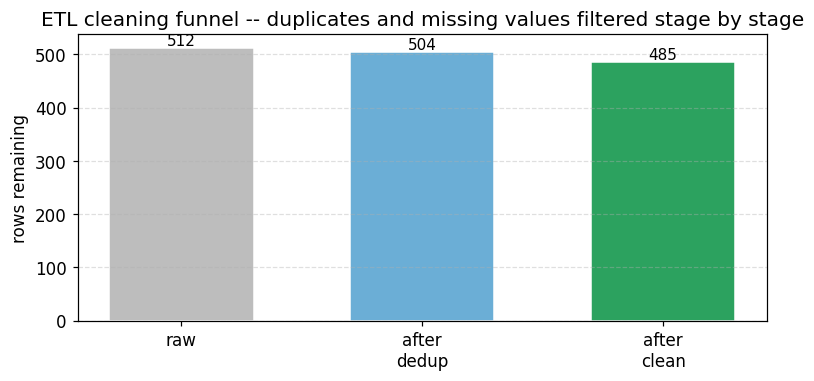

In [10]:

# Visualising the ETL funnel -- rows remaining after each stage.
stages = ["raw", "after\ndedup", "after\nclean"]
counts = [n_raw, n_dedup, n_clean]
colors = ["#bdbdbd", "#6baed6", "#2ca25f"]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
bars = ax.bar(stages, counts, color=colors, edgecolor="white", width=0.6)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c, f"{c}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("rows remaining")
ax.set_title("ETL cleaning funnel -- duplicates and missing values filtered stage by stage")
ax.grid(True, ls="--", alpha=0.4, axis="y")
plt.tight_layout()


> **Observe:** the raw observations passed through de-duplication and then missing-value
> removal, leaving only clean observations (see the funnel figure above for the counts
> removed). `filter`, `dropDuplicates` and `withColumn` are all **narrow
> transformations**, so they are cheap — no data moves between partitions (no shuffle).
> This cleaned `df_clean` is now the input to every aggregation — the ETL step that
> stops "garbage in, garbage out".

---
## 5. Aggregation — `groupBy().agg()`, and a reunion with Week 2

Now we compute in one line of Spark the very thing we hand-wrote in Week 2 — the **mean
temperature per station**: `groupBy("station").agg(...)`. In Week 2 we said "means
cannot simply be combined; you need a (sum, count) partial aggregate", and Spark does
that **partial aggregation** (partial sums per partition, merged after a shuffle)
automatically. All we have to do is verify numerically that the result **matches the
serial pandas computation**.

Aggregation has to gather the same key across partition boundaries, so it is a **wide
transformation** (it triggers a shuffle) — in contrast to the narrow transformations of
Section 4.


In [ ]:

agg = (
    df_clean.groupBy("station")
    .agg(
        F.count("*").alias("n"), # number of lines
        F.round(F.mean("temp"), 3).alias("mean_temp"), 
        F.round(F.min("temp"), 2).alias("min_temp"),
        F.round(F.max("temp"), 2).alias("max_temp"),
        F.round(F.stddev("temp"), 3).alias("std_temp"),
    )
    .orderBy("station")
) # plan
agg.show() # action


+-------+---+---------+--------+--------+--------+
|station|  n|mean_temp|min_temp|max_temp|std_temp|
+-------+---+---------+--------+--------+--------+
|    108|138|   25.954|   21.36|   29.86|   2.252|
|    112| 69|     24.3|   20.51|   28.34|   2.271|
|    133|139|     27.4|   23.25|   31.09|   2.292|
|    143| 69|     22.9|   18.84|   26.87|   2.309|
|    159| 70|   28.432|   24.42|   32.12|   2.204|
+-------+---+---------+--------+--------+--------+



In [12]:

# Cross-check: perform the same cleaning serially in pandas and compare the means (Week 2's 'serial ground truth').
pdf = df_clean.select("station", "temp").toPandas()
serial_mean = pdf.groupby("station")["temp"].mean().round(3)

spark_mean = {r["station"]: r["mean_temp"] for r in agg.collect()}
print(f"{'Station':>8}{'Spark mean':>13}{'pandas serial':>16}{'|diff|':>12}")
print("-" * 49)
max_err = 0.0
for s in sorted(spark_mean):
    d = abs(spark_mean[s] - serial_mean[s])
    max_err = max(max_err, d)
    print(f"{s:>8}{spark_mean[s]:>13.3f}{serial_mean[s]:>16.3f}{d:>12.2e}")
print("-" * 49)
print(f"maximum absolute difference = {max_err:.2e}")
assert max_err < 1e-6, "the Spark aggregation must not differ from the serial result"
print("-> Spark's automatic partial aggregation matches the serial result from Week 2.")


 Station   Spark mean   pandas serial      |diff|
-------------------------------------------------
     108       25.954          25.954    0.00e+00
     112       24.300          24.300    0.00e+00
     133       27.400          27.400    0.00e+00
     143       22.900          22.900    0.00e+00
     159       28.432          28.432    0.00e+00
-------------------------------------------------
maximum absolute difference = 0.00e+00
-> Spark's automatic partial aggregation matches the serial result from Week 2.


Attaching the **station names** to the aggregate makes the figure easier to read. For
that we **join** the two DataFrames on the `station` key. A join matches rows from different partitions by key, so it is a wide operation.


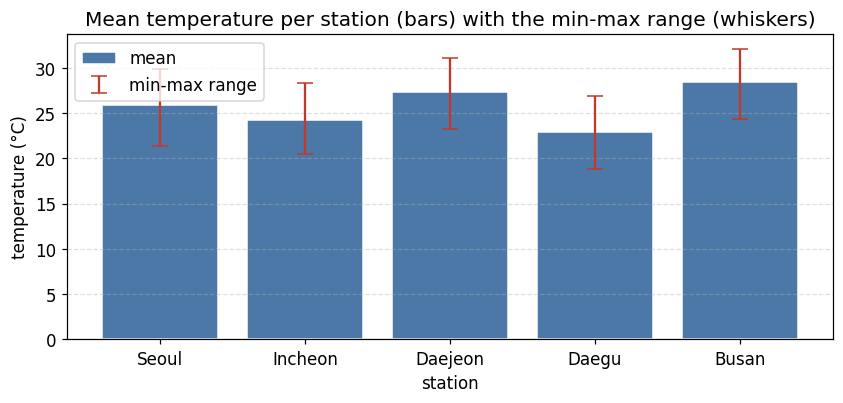

In [13]:

agg_named = (
    agg.join(stations_df.select("station", "name", "region"), on="station", how="left")
       .orderBy("station")
)
rows_named = agg_named.collect()
names = [r["name"] for r in rows_named]
means = [r["mean_temp"] for r in rows_named]
mins  = [r["min_temp"] for r in rows_named]
maxs  = [r["max_temp"] for r in rows_named]

fig, ax = plt.subplots(figsize=(7.8, 3.8))
x = np.arange(len(names))
ax.bar(x, means, color="#4c78a8", edgecolor="white", label="mean")
ax.errorbar(x, means, yerr=[np.array(means)-np.array(mins), np.array(maxs)-np.array(means)],
            fmt="none", ecolor="#c0392b", capsize=5, label="min-max range")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_xlabel("station"); ax.set_ylabel("temperature (°C)")
ax.set_title("Mean temperature per station (bars) with the min-max range (whiskers)")
ax.grid(True, ls="--", alpha=0.4, axis="y"); ax.legend()
plt.tight_layout()


Aggregation is not limited to stations — we can group **by hour** too. Let us extract
the **diurnal cycle** of the daily mean temperature with `groupBy("hour")` and check
that the afternoon peak we planted in the data is recovered.


hour with the highest mean temperature: 16:00 (pattern planted in the data: peak near 15:00)


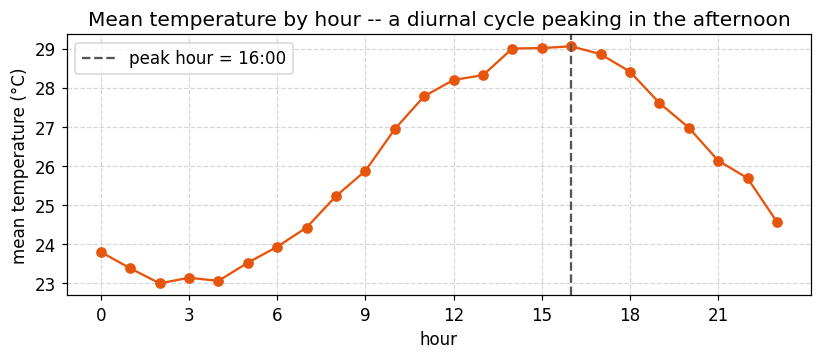

In [14]:

diurnal = (
    df_clean.groupBy("hour")
    .agg(F.round(F.mean("temp"), 3).alias("mean_temp"))
    .orderBy("hour")
    .toPandas()
)
peak_hour = int(diurnal.loc[diurnal["mean_temp"].idxmax(), "hour"])

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.plot(diurnal["hour"], diurnal["mean_temp"], "o-", color="#e6550d")
ax.axvline(peak_hour, ls="--", color="#555", label=f"peak hour = {peak_hour}:00")
ax.set_xlabel("hour"); ax.set_ylabel("mean temperature (°C)")
ax.set_title("Mean temperature by hour -- a diurnal cycle peaking in the afternoon")
ax.set_xticks(range(0, 24, 3))
ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()
print(f"hour with the highest mean temperature: {peak_hour}:00 (pattern planted in the data: peak near 15:00)")


> **Observe:** one call to `groupBy().agg()` gave us count, mean, min, max and stddev per
> station, and the mean **matched** the serial pandas computation to within $10^{-6}$ —
> Spark did automatically the (sum, count) partial aggregation we hand-wrote in Week 2.
> The hourly aggregation recovered the **afternoon-peaking diurnal cycle** exactly. Just
> remember that aggregation is a **wide transformation (a shuffle)** that gathers the same
> key across partitions — we confirm that with the query plan in Section 7.

---
## 6. Spark SQL — the same aggregation in SQL

Spark offers a SQL interface **fully equivalent** to the DataFrame API. Register a
DataFrame as a **temp view** and you can write standard SQL; internally both compile
down to the same optimizer (**Catalyst**), so the **results and the performance are
identical**. If your team is full of SQL people, use SQL; when embedding into a Python
pipeline, use the API — mix them to taste.

Let us rewrite the per-station aggregation of Section 5 in SQL and check that the two
results are **exactly** the same.


In [15]:

df_clean.createOrReplaceTempView("obs")
stations_df.createOrReplaceTempView("stations")

sql_agg = spark.sql('''
    SELECT station,
           COUNT(*)                        AS n,
           ROUND(AVG(temp), 3)             AS mean_temp,
           ROUND(MIN(temp), 2)             AS min_temp,
           ROUND(MAX(temp), 2)             AS max_temp,
           ROUND(STDDEV(temp), 3)          AS std_temp
    FROM obs
    GROUP BY station
    ORDER BY station
''')
sql_agg.show()

# Verify row by row that this is identical to the DataFrame API result (agg, Section 5).
api_rows = [tuple(r) for r in agg.collect()]
sql_rows = [tuple(r) for r in sql_agg.collect()]
assert api_rows == sql_rows, "SQL and DataFrame API results must not differ"
print("verified: SQL result == DataFrame API result (exactly identical).")


+-------+---+---------+--------+--------+--------+
|station|  n|mean_temp|min_temp|max_temp|std_temp|
+-------+---+---------+--------+--------+--------+
|    108|138|   25.954|   21.36|   29.86|   2.252|
|    112| 69|     24.3|   20.51|   28.34|   2.271|
|    133|139|     27.4|   23.25|   31.09|   2.292|
|    143| 69|     22.9|   18.84|   26.87|   2.309|
|    159| 70|   28.432|   24.42|   32.12|   2.204|
+-------+---+---------+--------+--------+--------+

verified: SQL result == DataFrame API result (exactly identical).


The power of SQL is how naturally it weaves **join and group by** together. Let us join
the observations (`obs`) with the station metadata (`stations`) and compute the mean
temperature **per region** — a preview of Week 4's space-time aggregation.


In [16]:

region_agg = spark.sql('''
    SELECT s.region,
           COUNT(*)               AS n,
           ROUND(AVG(o.temp), 3)  AS mean_temp
    FROM obs o
    JOIN stations s ON o.station = s.station
    GROUP BY s.region
    ORDER BY mean_temp DESC
''')
region_agg.show()


+-----------+---+---------+
|     region|  n|mean_temp|
+-----------+---+---------+
|Chungcheong|139|     27.4|
|   Yeongnam|139|   25.686|
|    Capital|207|   25.403|
+-----------+---+---------+



**Window functions** do not fold rows the way group by does; they attach things like
"rank or moving average within each group" to every row. Let us pull out the **two
hottest moments** at each station: rank within a station with `PARTITION BY station
ORDER BY temp DESC` and keep only the top two.


In [17]:

top_hot = spark.sql('''
    WITH ranked AS (
        SELECT station, datetime, temp,
               ROW_NUMBER() OVER (PARTITION BY station ORDER BY temp DESC) AS rk
        FROM obs
    )
    SELECT station, datetime, temp, rk
    FROM ranked
    WHERE rk <= 2
    ORDER BY station, rk
''')
top_hot.show(truncate=False)
print("-> window function: ranking within each station pulled out its hottest moments.")


+-------+----------------+-----+---+
|station|datetime        |temp |rk |
+-------+----------------+-----+---+
|108    |2025-08-03T15:00|29.86|1  |
|108    |2025-08-01T16:00|29.86|2  |
|112    |2025-08-01T15:00|28.34|1  |
|112    |2025-08-03T16:00|28.14|2  |
|133    |2025-08-02T16:00|31.09|1  |
|133    |2025-08-01T14:00|30.91|2  |
|143    |2025-08-01T17:00|26.87|1  |
|143    |2025-08-02T13:00|26.55|2  |
|159    |2025-08-03T15:00|32.12|1  |
|159    |2025-08-02T16:00|31.92|2  |
+-------+----------------+-----+---+

-> window function: ranking within each station pulled out its hottest moments.


Finally, a **UDF** (User-Defined Function): domain logic that is awkward to express
with built-ins, defined as a Python function and used from SQL or the DataFrame API.
(Be aware that a UDF pays a JVM↔Python round-trip cost, so **reach for built-ins
first**.) Let us register a simple UDF that classifies temperature into comfort bands.


In [16]:

@F.udf(returnType=T.StringType())
def comfort(temp):
    # An example of domain logic: comfort band (the built-in `when` could do this too;
    # this is here to show the shape of a UDF).
    if temp is None:
        return "unknown"
    if temp >= 29:
        return "sweltering"
    if temp >= 26:
        return "hot"
    return "comfortable"

spark.udf.register("comfort", comfort)     # register so SQL can use it too

spark.sql('''
    SELECT comfort(temp) AS band, COUNT(*) AS n, ROUND(AVG(temp), 2) AS mean_temp
    FROM obs
    GROUP BY comfort(temp)
    ORDER BY mean_temp
''').show()


+-----------+---+---------+
|       band|  n|mean_temp|
+-----------+---+---------+
|comfortable|241|    23.66|
|        hot|157|    27.46|
| sweltering| 87|    30.16|
+-----------+---+---------+



> **Observe:** writing the same aggregation in SQL produced **not a single differing
> row** compared with the DataFrame API — both compile through Catalyst. SQL weaves
> `JOIN`, window functions (`ROW_NUMBER() OVER (...)`) and UDFs together naturally,
> expressing queries such as "mean per region" or "each station's hottest moment"
> declaratively. Write only **what** you want and the engine decides **how** to execute it
> in a distributed way — we look into that 'how' in the next section.

---
## 7. Lazy execution — query plans and cache

Spark's defining property: **transformations do not execute immediately.** `select`,
`filter` and `groupBy` only stack up "what to do" as a **plan (lineage)**; only when an
**action** such as `count`, `show` or `collect` is called does Spark optimise the whole
plan and run it. This **lazy evaluation** lets Spark drop unnecessary work and reorder
operations.

| Kind | Examples | When it runs |
|---|---|---|
| **Transformation** | `select`, `filter`, `withColumn`, `groupBy`, `join` | deferred (only the plan grows) |
| **Action** | `count`, `show`, `collect`, `write`, `toPandas` | immediately (the plan executes) |

Let us read the **physical query plan** Spark builds with `explain()`. An aggregation
query contains an `Exchange` (= a shuffle) that redistributes the partitions — that is
the wide transformation mentioned in Section 5.


In [17]:

plan_query = df_clean.groupBy("station").agg(F.mean("temp").alias("m"))
print("=== physical query plan (groupBy aggregation) ===")
plan_query.explain(mode="formatted")


=== physical query plan (groupBy aggregation) ===
== Physical Plan ==
AdaptiveSparkPlan (9)
+- HashAggregate (8)
   +- Exchange (7)
      +- HashAggregate (6)
         +- HashAggregate (5)
            +- Exchange (4)
               +- HashAggregate (3)
                  +- Filter (2)
                     +- Scan csv  (1)


(1) Scan csv 
Output [4]: [station#52, datetime#53, temp#54, humidity#55]
Batched: false
Location: InMemoryFileIndex [file:/var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk03_azdq6hv6/aws_obs.csv]
PushedFilters: [IsNotNull(temp), IsNotNull(humidity), GreaterThan(temp,-90.0), GreaterThan(humidity,-90.0)]
ReadSchema: struct<station:int,datetime:string,temp:double,humidity:double>

(2) Filter
Input [4]: [station#52, datetime#53, temp#54, humidity#55]
Condition : (((isnotnull(temp#54) AND isnotnull(humidity#55)) AND (temp#54 > -90.0)) AND (humidity#55 > -90.0))

(3) HashAggregate
Input [4]: [station#52, datetime#53, temp#54, humidity#55]
Keys [4]: [station#52

---
## 🔬 Exercises

The problems below extend today's ETL, aggregation and SQL one step at a time. A working
reference solution follows each one, so try it yourself first and then compare.


**Exercise 1 — aggregate humidity too.** Add the **mean, minimum and maximum of
humidity** to `groupBy("station")`. Then print the **mean temperature and mean humidity**
side by side to check whether they are negatively correlated (the hotter, the drier).


In [21]:

ex1 = (df_clean.groupBy("station")
       .agg(F.round(F.mean("temp"), 2).alias("mean_temp"),
            F.round(F.mean("humidity"), 1).alias("mean_rh"),
            F.round(F.min("humidity"), 1).alias("min_rh"),
            F.round(F.max("humidity"), 1).alias("max_rh"))
       .orderBy("station"))
ex1.show()

p = ex1.toPandas()
corr = np.corrcoef(p["mean_temp"], p["mean_rh"])[0, 1]
print(f"correlation of mean temperature vs mean humidity = {corr:.3f}  (negative means 'hotter is drier')")


+-------+---------+-------+------+------+
|station|mean_temp|mean_rh|min_rh|max_rh|
+-------+---------+-------+------+------+
|    108|    25.95|   67.1|  54.4|  79.4|
|    112|     24.3|   69.3|  60.4|  79.0|
|    133|     27.4|   64.9|  54.8|  75.3|
|    143|     22.9|   71.5|  60.7|  82.1|
|    159|    28.43|   63.2|  54.1|  71.4|
+-------+---------+-------+------+------+

correlation of mean temperature vs mean humidity = -0.999  (negative means 'hotter is drier')


**Exercise 2 — hourly ranking with a SQL window.** For each **hour**, find which station
was the hottest using `RANK() OVER (PARTITION BY hour ORDER BY mean temperature DESC)`.
Hint: build the mean per (hour, station) first, then put the window on top of it. Print
only the winners.


In [22]:

ex2 = spark.sql('''
    WITH hs AS (
        SELECT hour, station, AVG(temp) AS mt
        FROM obs GROUP BY hour, station
    ),
    ranked AS (
        SELECT hour, station, ROUND(mt, 2) AS mean_temp,
               RANK() OVER (PARTITION BY hour ORDER BY mt DESC) AS rk
        FROM hs
    )
    SELECT hour, station, mean_temp FROM ranked WHERE rk = 1 ORDER BY hour
''')
ex2.show(24)
top_counts = ex2.groupBy("station").count().orderBy(F.desc("count"))
print("the station that took first place in the most hours:")
top_counts.show()


+----+-------+---------+
|hour|station|mean_temp|
+----+-------+---------+
|   0|    159|    26.41|
|   1|    159|    25.86|
|   2|    159|    25.79|
|   3|    159|    25.59|
|   4|    159|    25.74|
|   5|    159|    25.31|
|   6|    159|    26.05|
|   7|    159|    27.66|
|   8|    159|    27.58|
|   9|    159|     27.5|
|  10|    159|    29.67|
|  11|    159|    29.74|
|  12|    159|    30.63|
|  13|    159|    31.08|
|  14|    159|    31.32|
|  15|    159|    31.79|
|  16|    159|    31.43|
|  17|    159|    30.58|
|  18|    159|    30.27|
|  19|    159|    29.92|
|  20|    159|    29.45|
|  21|    159|     28.8|
|  22|    159|    27.69|
|  23|    159|    27.01|
+----+-------+---------+

the station that took first place in the most hours:
+-------+-----+
|station|count|
+-------+-----+
|    159|   24|
+-------+-----+



**Exercise 3 — removing physical outliers.** Besides the missing sentinel, add a filter
that treats **physically impossible values** in August observations (e.g. `temp < 10` or
`temp > 45`) as outliers and removes them. Count how many extra rows get filtered and
compare how much the per-station means change before and after. (There may be almost
none in this data — that in itself confirms "this dataset is clean".)


In [23]:

before = df_clean.count()
df_phys = df_clean.filter((F.col("temp") >= 10) & (F.col("temp") <= 45))
after = df_phys.count()
print(f"physical range (10-45 C) filter: {before} -> {after} rows (removed {before-after})")

m_before = {r["station"]: r["m"] for r in
            df_clean.groupBy("station").agg(F.round(F.mean("temp"),3).alias("m")).collect()}
m_after = {r["station"]: r["m"] for r in
           df_phys.groupBy("station").agg(F.round(F.mean("temp"),3).alias("m")).collect()}
print(f"{'Station':>8}{'before':>10}{'after':>10}{'change':>10}")
print("-" * 38)
for s in sorted(m_before):
    print(f"{s:>8}{m_before[s]:>10.3f}{m_after[s]:>10.3f}{m_after[s]-m_before[s]:>10.3f}")


physical range (10-45 C) filter: 485 -> 485 rows (removed 0)
 Station    before     after    change
--------------------------------------
     108    25.954    25.954     0.000
     112    24.300    24.300     0.000
     133    27.400    27.400     0.000
     143    22.900    22.900     0.000
     159    28.432    28.432     0.000


---
## Summary

Today we rewrote on a real engine, **Spark**, the **distributed aggregation we hand-wrote
in Week 2**, and completed a **basic ETL pipeline** (this week's deliverable) that turns
raw observations into a clean table:

- **SparkSession** (local mode) and the driver–executor–**partition** structure. We saw
  `range` split evenly across the cores — the engine's version of Week 2's 'blocks'.
- **Extract:** reading a CSV with an explicit schema is faster and more reproducible than
  inferSchema.
- **Transform:** we stripped missing values and duplicates and derived new columns with
  `filter`, `dropDuplicates` and `withColumn` (narrow transformations, no shuffle).
- **Aggregation:** the result of `groupBy().agg()` matched the serial pandas computation
  to within $10^{-6}$ — Spark performs the (sum, count) **partial aggregation**
  automatically.
- **Spark SQL:** the result of a temp view plus `spark.sql` did **not differ by a single
  row** from the DataFrame API (the same Catalyst engine). We also covered `join`, window
  functions and UDFs.
- **Lazy & cache:** we read the partial-aggregate → **Exchange (shuffle)** → final
  aggregate plan in `explain()`.

> **Where are we in the pipeline?** Today's ETL implements the closed-loop twin's
> **"① ingest observations → ② align and aggregate in space-time"** stretch in Spark. Next
> week (Week 4) **Spark II** takes this further into **space-time observation
> aggregation** (time and space grids, windows), and in Week 5 we grow today's persistence
> into the submitted **M0 baseline**.

### Further Exercises

1. If you save `df_clean` **partitioned** by `station` (`partitionBy("station")`), how
   does the Parquet directory structure change? What is the benefit when reading only one
   station?
2. Compare the `explain()` of a DataFrame read with `inferSchema=True` against one read
   with an explicit schema — can you see the difference at the read stage?
3. Set `spark.sql.shuffle.partitions` to 2 and to 64 and time the aggregation of Section
   5. Why does having too many partitions slow small data down?
4. Rewrite the UDF `comfort` as a built-in `when` expression and compare with `explain()`
   — why do built-ins optimise better than UDFs?
5. To compute the **standard error** of the per-station mean, which partial aggregates
   ($\sum x$, $\sum x^2$, $n$) must you collect? Implement it with `groupBy().agg()`.


---
Finally we tidy up the SparkSession (releasing its resources). Real pipelines close the
session when the job is done too.


In [25]:

spark.stop()
print("SparkSession stopped. Today's ETL outputs:", os.path.join(WORK, "etl_out"))
print("Well done -- next week Spark II continues with space-time aggregation.")


SparkSession stopped. Today's ETL outputs: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk03_azdq6hv6/etl_out
Well done -- next week Spark II continues with space-time aggregation.
